In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [14]:
# to create a grid, we'll first create 3 1D arrays including ghost cells and pass them to the Grid constructor
# note that a 1-cell array is needed even if you don't intend to solve along that direction. pyFLD will simply
# not solve along directions with only 1 cell, but the internal code structure is always spatially 3D
xi = fld.grid.get_domain_with_ghosts(1, 2, Nx=100) * u.cm
yi = fld.grid.get_domain_with_ghosts(0, 1, Nx=50) * u.cm
zi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
grid = fld.grid.Grid(xi, yi, zi, geometry='cartesian')

# now we create a fluid object
Gas = fld.fluids.Gas(grid=grid, debug=False, name='basic')

# Next, this object needs a density and temperature. We can use the grid object to compute this.
# Again, these should be 3D arrays. For this problem we'll use constant density.
E0 = 1 * u.erg / u.cm**3
rho = 1 * u.g/u.cm**3 * np.ones(grid.shape)
tmp = fld.tools.Er_to_T(E0) * np.ones(grid.shape)

# Now set them in the Gas object.
Gas.set_density(rho)
Gas.set_temperature(tmp)

# Then, we need to set opacities. We'll set a constant value for both Rosseland and Planck
# via a function call. pyFLD expects the function to receive the fluid object:
Gas.enroll_kappaR(lambda f: 1.0 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1.0 * u.cm**2/u.g)

# Finally, call the setup() method to compute everything else internally
Gas.setup()

# to create the context for the radiative problem, we provide the list of fluids (in this case 1).
# For this problem we'll assume a constant flux limiter of 1/3 for simplicity
Box = fld.FLD.RadiativeEnvironment([Gas], verbose=True, debug=False, name='box',
                                   constant_fluxlimiter=True)#, preconditioner='jacobi')

# We need to tell the FLD object how to handle boundary conditions for any quantity
# For this we need to set the behavior of each side: x_beg, x_end, y_beg, y_end, z_beg, z_end.
# The currently supported options are zero-gradient ("reflective") or fixed value for E_rad.
# For this problem we'll set a combination of boundaries:
# fixed value in x_beg and y_beg (equal), a different value in y_end, and reflective in x_end
val, ref = fld.grid.BOUNDARY_FIXEDVALUE, fld.grid.BOUNDARY_REFLECTIVE
bounds = [val, ref, val, val, ref, ref]
vals   = [E0, 0, E0, 2*E0, 0, 0]
Box.declare_boundaries(bounds, vals)

In [15]:
# Before any solving, let's plot the Box state.
# All fluids include ghost cells, which we probably don't want to plot.
# For this, we can use the slicers "act1/2/3" or "active" to select the active domain
# in 1D quantities in the x1/2/3 directions, or 3D quantities, respectively

x = grid.x1[grid.act1].to_value('cm')
y = grid.x2[grid.act2].to_value('cm')
z = grid.x3[grid.act3].to_value('cm')

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in z

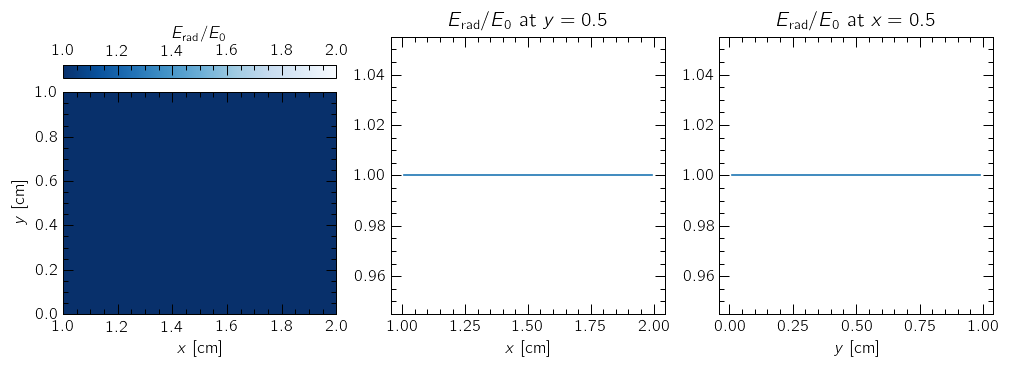

In [16]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[y.size//2]) # slice along x at the middle of the grid
ax[2].plot(y, Er_[:,x.size//2]) # slice along y at the middle of the grid

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ at $y=0.5$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ at $x=0.5$')

plt.show()

In [17]:
# now perform some steps with a large enough timestep...
# note that the diffusion coefficient is ~ 1/3 c / (kappa rho) ~ 1e8 cm2/s,
# which for a characteristic length of 1cm implies a diffusion timescale of 1e-8 s.
# However, this is still an implicit solver: stability doesn't mean accuracy.
# For this reason, we give it 10 iterations to converge to a steady state.

# This particular problem is a bit stiff and takes quite a few iterations to converge.
# In more realistic conditions we'll see it usually takes a small fraction of that

for _ in range(10): Box.advance(dt=1e10 * u.s)

RadiativeEnvironment 'box': Converged in 31 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.


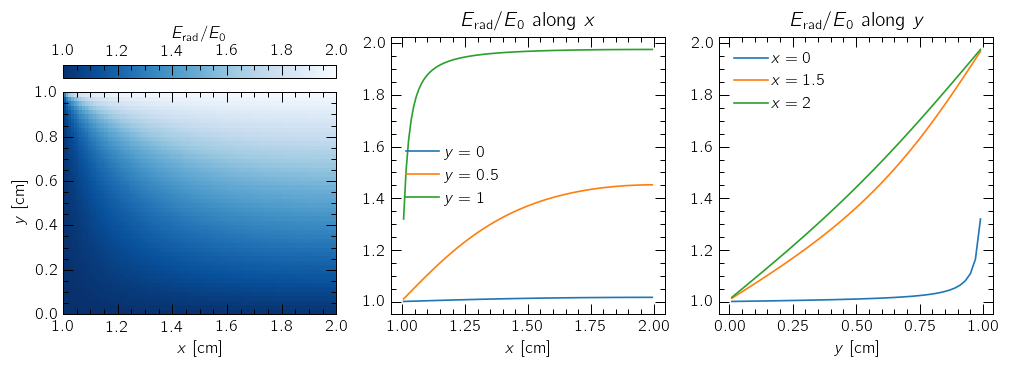

In [18]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

In [19]:
# We see what we expect: Erad is =E0 at x=0, y=0, =2E0 at y=1, and dE/dx = 0 at x=2.
# Note: along y for x=0 (blue line in 3rd panel), we see that the line doesn't actually connect to E = 2E0.
# This is intentional: the boundary condition is satisfied at cell _edges_, but we're plotting cell centers,
# i.e., we don't have access to that datapoint. Nevertheless, its behavior is correct.
# The same is true for the green line in the 2nd panel.

In [20]:
# let's change the boundary conditions: E=E0 at xbeg, xend, and E=2E0 at ybeg, yend
# Note that we're not restarting the model, just continuing from the previous state.
# This doesn't really matter much as we're anyway iterating towards a steady state.

bounds = [val, val, val, val, ref, ref]
vals   = [E0, E0, 2*E0, 2*E0, 0, 0]
Box.declare_boundaries(bounds, vals)
for _ in range(10): Box.advance(dt=1e10 * u.s)

RadiativeEnvironment 'box': Converged in 28 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.


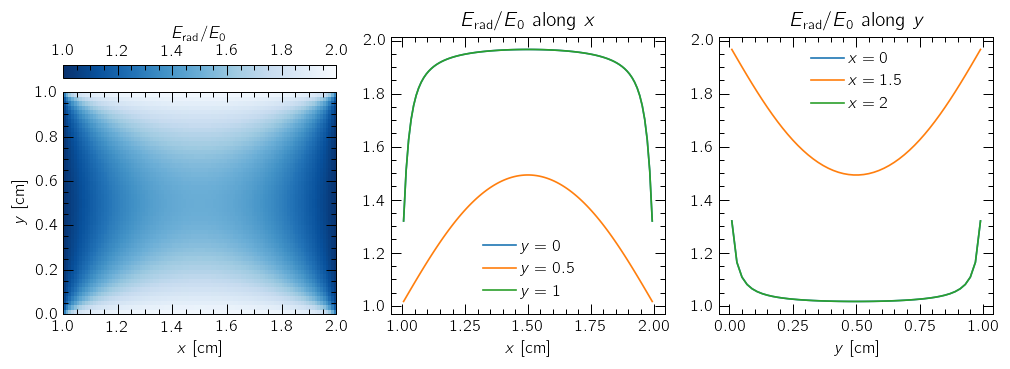

In [21]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

In [22]:
# different boundary conditions: E=E0 at xbeg, ybeg, and E=2E0 at xend, yend

bounds = [val, val, val, val, ref, ref]
vals   = [E0, 2*E0, E0, 2*E0, 0, 0]
Box.declare_boundaries(bounds, vals)
for _ in range(10): Box.advance(dt=1e10 * u.s)

RadiativeEnvironment 'box': Converged in 26 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.


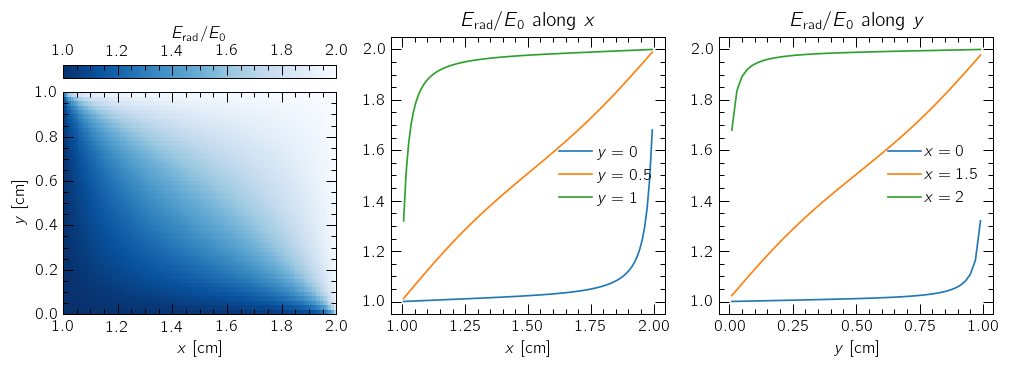

In [23]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

In [24]:
# yet different: E=E0 at xbeg, E=2E0 at xend, reflective along y
# This one has an easy equilibrium state: straight line from E0 to 2*E0 along x

bounds = [val, val, ref, ref, ref, ref]
vals   = [E0, 2*E0, 0, 0, 0, 0]
Box.declare_boundaries(bounds, vals)

# try playing with the relative tolerance of the solver and checking the error in the plots!
Box.configure_solver(rtol=1e-12)
for _ in range(10): Box.advance(dt=1e10 * u.s)

RadiativeEnvironment 'box': Converged in 38 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.


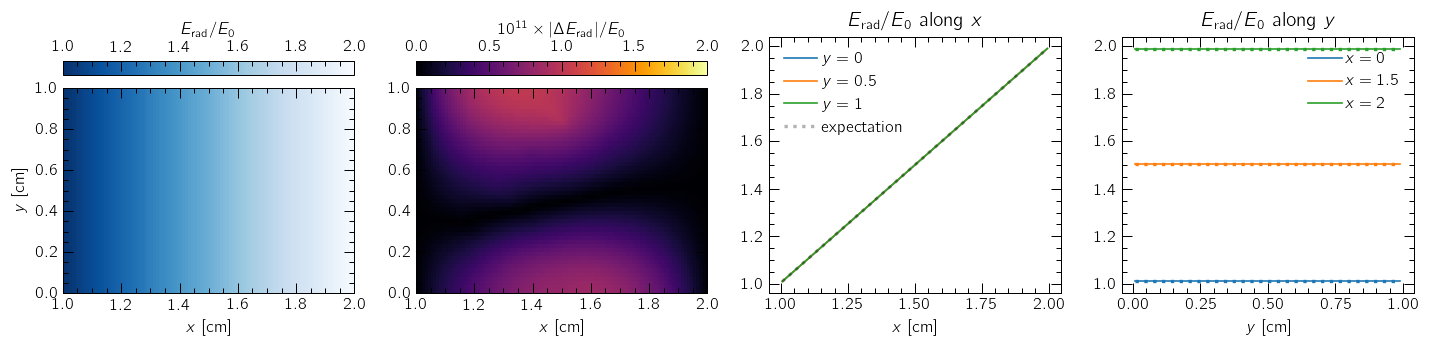

In [31]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)

xstart, xend = grid.x1[grid.ibeg-1].to('cm'), grid.x1[grid.iend+1].to('cm')
Estart, Eend = Box.boundary_val[0], Box.boundary_val[1]
Eexp = Estart + (Eend-Estart)/(xend-xstart) * (x*u.cm - xstart)
Eexp = Eexp.to_value(E0) * np.ones(y.shape)[:,None] # make it 2D

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
img = ax[1].pcolormesh(x, y, 1e11 * np.abs(Er_/Eexp - 1), vmin=0, vmax=2, cmap=plt.cm.inferno)
cb = plt.colorbar(img, ax=ax[1], location='top')
cb.set_label(r'$10^{11}\times|\Delta E_\mathrm{rad}| / E_0$')

ax[2].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[2].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[2].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[3].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[3].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[3].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[2].plot(x, Eexp[0], label='expectation', linestyle=':', c='k', alpha=0.3, lw=2)
ax[3].plot(y, Eexp[:,0], linestyle=':', c='C0', lw=2)
ax[3].plot(y, Eexp[:,x.size//2], linestyle=':', c='C1', lw=2)
ax[3].plot(y, Eexp[:,-1], linestyle=':', c='C2', lw=2)

ax[2].legend()
ax[3].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$x$ [cm]')
ax[3].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[3].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

fig.tight_layout()
plt.show()